In [1]:
# !pip install -q "transformers>=4.44" "datasets>=2.18" accelerate scikit-learn matplotlib seaborn
# Optional (for PEFT/LoRA later):  # !pip install -q peft

import os, random, numpy as np, pandas as pd
import warnings

warnings.filterwarnings("ignore")

# (Your proxy/env)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "true")
os.environ["https_proxy"] = "http://10.101.159.162:7890"
os.environ["http_proxy"] = "http://10.101.159.162:7890"

import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

In [2]:
DATA_DIR = "../data"
CSV_RED = os.path.join(DATA_DIR, "WineQuality-RedWine.csv")  # UCI red wine

# Results produced earlier
ABLATION_RESULTS = "runs/gpt2_prompt_tabular/ablation/ablation_results.csv"
MULTI_SEED_SUM = "runs/gpt2_prompt_tabular/validation/multi_seed_summary.csv"

# Model/training
MODEL_NAME = "gpt2"
MAX_LENGTH = 256
BATCH_TRAIN = 16
BATCH_EVAL = 32
EPOCHS = 5
LR = 5e-5
WEIGHT_DECAY = 0.01

OUT_DIR = "runs/gpt2_prompt_tabular/final"
FIG_DIR = os.path.join(OUT_DIR, "figs")
os.makedirs(FIG_DIR, exist_ok=True)

In [3]:
df = pd.read_csv(CSV_RED)
assert "quality" in df.columns

df["label"] = (df["quality"] >= 7).astype(int)
feature_cols = [c for c in df.columns if c not in ["quality", "label"]]
id2label = {0: "not_good", 1: "good"}
label2id = {"not_good": 0, "good": 1}

from sklearn.model_selection import train_test_split

df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
X_train, X_test = train_test_split(
    df, test_size=0.2, random_state=SEED, stratify=df["label"]
)
X_train, X_val = train_test_split(
    X_train, test_size=0.2, random_state=SEED, stratify=X_train["label"]
)

print("Splits:", X_train.shape, X_val.shape, X_test.shape)

Splits: (1023, 13) (256, 13) (320, 13)


In [4]:
def serialize_row(row, cols, template="bullet"):
    pretty = {
        "fixed acidity": ("fixed acidity", "g/dm^3"),
        "volatile acidity": ("volatile acidity", "g/dm^3"),
        "citric acid": ("citric acid", "g/dm^3"),
        "residual sugar": ("residual sugar", "g/dm^3"),
        "chlorides": ("chlorides", "g/dm^3"),
        "free sulfur dioxide": ("free sulfur dioxide", "mg/dm^3"),
        "total sulfur dioxide": ("total sulfur dioxide", "mg/dm^3"),
        "density": ("density", "g/cm^3"),
        "pH": ("pH", ""),
        "sulphates": ("sulphates", "g/dm^3"),
        "alcohol": ("alcohol", "% vol"),
    }

    def nm(c):
        return pretty.get(c, (c, ""))[0]

    def un(c):
        return pretty.get(c, (c, ""))[1]

    if template == "bullet":
        lines = ["The following red wine has these lab measurements:"]
        for c in cols:
            lines.append(f"- {nm(c)}: {row[c]} {un(c)}".rstrip())
        lines += [
            "",
            "Question: Is this wine high quality (good) or not good?",
            "Answer:",
        ]
        return "\n".join(lines)
    else:
        parts = []
        for c in cols:
            u = un(c)
            parts.append(f"{nm(c)} {row[c]}{(' ' + u) if u else ''}".strip())
        body = ", ".join(parts[:-1]) + (", and " + parts[-1] if parts else "")
        return f"Given a red wine with {body}. Is this wine high quality (good) or not good? Answer:"


# Mutual information top-k selection (on TRAIN only)
from sklearn.feature_selection import mutual_info_classif
import numpy as np


def select_topk_features(X_df, y, all_cols, k=None):
    if (k is None) or (k >= len(all_cols)):
        return list(all_cols)
    mi = mutual_info_classif(X_df[all_cols].values, y.values, random_state=SEED)
    order = np.argsort(mi)[::-1]
    return [all_cols[i] for i in order[:k]]


FS_CACHE = {
    k: select_topk_features(X_train, X_train["label"], feature_cols, k)
    for k in [3, 5, 7, 9]
}
FS_CACHE

{3: ['alcohol', 'sulphates', 'volatile acidity'],
 5: ['alcohol',
  'sulphates',
  'volatile acidity',
  'fixed acidity',
  'citric acid'],
 7: ['alcohol',
  'sulphates',
  'volatile acidity',
  'fixed acidity',
  'citric acid',
  'density',
  'chlorides'],
 9: ['alcohol',
  'sulphates',
  'volatile acidity',
  'fixed acidity',
  'citric acid',
  'density',
  'chlorides',
  'total sulfur dioxide',
  'residual sugar']}

In [5]:
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, GPT2ForSequenceClassification
from transformers import DataCollatorWithPadding, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, classification_report

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


def build_text(df_in, cols, template):
    return df_in.apply(lambda r: serialize_row(r, cols, template), axis=1)


def to_hf(df_in):
    return Dataset.from_pandas(df_in[["text", "label"]].reset_index(drop=True))


def make_tok_ds(tr, va, te, max_len=MAX_LENGTH):
    def tok(b):
        return tokenizer(b["text"], truncation=True, max_length=max_len)

    raw = DatasetDict({"train": to_hf(tr), "validation": to_hf(va), "test": to_hf(te)})
    return raw.map(tok, batched=True, remove_columns=["text"])


def run_one(seed, template="bullet", top_k=None, epochs=EPOCHS, lr=LR):
    cols = (
        FS_CACHE[top_k]
        if top_k in FS_CACHE
        else (
            feature_cols
            if top_k in [None, "all"]
            else select_topk_features(
                X_train, X_train["label"], feature_cols, int(top_k)
            )
        )
    )

    tr, va, te = X_train.copy(), X_val.copy(), X_test.copy()
    for d in (tr, va, te):
        d["text"] = build_text(d, cols, template)
    tok = make_tok_ds(tr, va, te)

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    model = GPT2ForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        pad_token_id=tokenizer.pad_token_id,
        id2label=id2label,
        label2id=label2id,
    ).to(DEVICE)

    def metrics(ep):
        logits, labels = ep
        preds = logits.argmax(-1)
        return {
            "accuracy": float(accuracy_score(labels, preds)),
            "f1_macro": float(f1_score(labels, preds, average="macro")),
        }

    out_dir = os.path.join(
        OUT_DIR, f"seed{seed}_{template}_topk{top_k if top_k else 'all'}"
    )
    args = TrainingArguments(
        output_dir=out_dir,
        logging_dir=os.path.join(out_dir, "logs"),
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        learning_rate=lr,
        num_train_epochs=epochs,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
        seed=seed,
    )
    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tok["train"],
        eval_dataset=tok["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=metrics,
    )
    trainer.train()
    pred = trainer.predict(tok["test"])
    y_true, y_pred = pred.label_ids, pred.predictions.argmax(-1)
    return {
        "seed": seed,
        "template": template,
        "top_k": (top_k if top_k else "all"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "accuracy": accuracy_score(y_true, y_pred),
        "tok": tok,
        "trainer": trainer,
    }

In [6]:
# We prefer per-seed detail from ABLATION_RESULTS; if not present we use MULTI_SEED_SUM.
candidates = None

if os.path.exists(MULTI_SEED_SUM):
    ms = pd.read_csv(MULTI_SEED_SUM)
    top2 = ms.sort_values("f1_mean", ascending=False).head(2)
    candidates = [
        {
            "name": f"C{i+1}",
            "template": r["template"],
            "top_k": (None if str(r["top_k"]).lower() == "all" else int(r["top_k"])),
        }
        for i, r in top2.reset_index(drop=True).iterrows()
    ]

elif os.path.exists(ABLATION_RESULTS):
    ab = pd.read_csv(ABLATION_RESULTS)
    # pick by mean F1 over seeds
    top2 = (
        ab.groupby(["template", "top_k"])
        .agg(f1_mean=("test_f1_macro", "mean"))
        .reset_index()
        .sort_values("f1_mean", ascending=False)
        .head(2)
    )
    candidates = [
        {
            "name": f"C{i+1}",
            "template": r.template,
            "top_k": (
                None if str(r.top_k).lower() in {"none", "all", "nan"} else int(r.top_k)
            ),
        }
        for i, r in top2.iterrows()
    ]

else:
    # Safe fallback if no CSVs are present
    candidates = [
        {"name": "C1", "template": "bullet", "top_k": 5},
        {"name": "C2", "template": "inline", "top_k": None},
    ]

candidates

[{'name': 'C1', 'template': 'inline', 'top_k': 7},
 {'name': 'C2', 'template': 'bullet', 'top_k': 7}]

In [7]:
from scipy.stats import wilcoxon
import numpy as np, pandas as pd

SEEDS = [42, 43, 44, 45, 46]  # match your earlier runs

scores = {}
for cand in candidates:
    f1s = []
    for s in SEEDS:
        out = run_one(seed=s, template=cand["template"], top_k=cand["top_k"])
        f1s.append(out["f1_macro"])
    scores[cand["name"]] = f1s
    print(cand["name"], cand["template"], cand["top_k"], "F1s:", np.round(f1s, 4))

A, B = candidates[0]["name"], candidates[1]["name"]
stat, p = wilcoxon(scores[A], scores[B], zero_method="wilcox", alternative="two-sided")
print(f"\nWilcoxon signed-rank (F1): {A} vs {B} -> stat={stat}, p={p:.4g}")

Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/320 [00:00<?, ?it/s]

...

{'eval_loss': 0.33024168014526367, 'eval_accuracy': 0.8671875, 'eval_f1_macro': 0.6361204013377927, 'eval_runtime': 16.0846, 'eval_samples_per_second': 15.916, 'eval_steps_per_second': 0.497, 'epoch': 4.0}


  0%|          | 0/8 [00:00<?, ?it/s]

{'eval_loss': 0.34340423345565796, 'eval_accuracy': 0.86328125, 'eval_f1_macro': 0.46331236897274636, 'eval_runtime': 13.637, 'eval_samples_per_second': 18.772, 'eval_steps_per_second': 0.587, 'epoch': 5.0}
{'train_runtime': 1304.3097, 'train_samples_per_second': 3.922, 'train_steps_per_second': 0.245, 'train_loss': 0.3880244493484497, 'epoch': 5.0}


  0%|          | 0/10 [00:00<?, ?it/s]

C2 bullet 7 F1s: [0.6709 0.464  0.6526 0.464  0.6911]

Wilcoxon signed-rank (F1): C1 vs C2 -> stat=0.0, p=0.06789


In [8]:
# Pick winner by higher mean F1 (or by p-value + mean if indistinguishable)
means = {k: np.mean(v) for k, v in scores.items()}
winner = max(means, key=means.get)
winner_spec = [c for c in candidates if c["name"] == winner][0]
winner_spec

# Train a fresh model on winner to get logits for calibration
res = run_one(seed=SEED, template=winner_spec["template"], top_k=winner_spec["top_k"])
trainer, tok = res["trainer"], res["tok"]

# --- threshold tuning on validation ---
from sklearn.metrics import f1_score
import numpy as np

val_logits = trainer.predict(tok["validation"]).predictions
p1_val = np.exp(val_logits[:, 1]) / np.exp(val_logits).sum(axis=1)
y_val = np.array(tok["validation"]["label"])

best_t, best_f1 = 0.5, -1
for t in np.linspace(0.3, 0.7, 41):
    f1 = f1_score(y_val, (p1_val >= t).astype(int), average="macro")
    if f1 > best_f1:
        best_t, best_f1 = t, f1
print("Best threshold on val:", round(best_t, 3), "Val F1:", round(best_f1, 4))

# --- apply to test ---
test_logits = trainer.predict(tok["test"]).predictions
p1_test = np.exp(test_logits[:, 1]) / np.exp(test_logits).sum(axis=1)
y_test = np.array(tok["test"]["label"])
f1_thresh = f1_score(y_test, (p1_test >= best_t).astype(int), average="macro")
print("Thresholded Test F1:", round(f1_thresh, 4))

Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/320 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

Best threshold on val: 0.35 Val F1: 0.6527


  0%|          | 0/10 [00:00<?, ?it/s]

Thresholded Test F1: 0.7139


In [9]:
USE_LORA = True
try:
    from peft import LoraConfig, get_peft_model
except Exception as e:
    print("PEFT not installed; set USE_LORA=False or pip install peft")
    USE_LORA = False

if USE_LORA:
    from transformers import GPT2ForSequenceClassification, TrainingArguments, Trainer
    from sklearn.metrics import accuracy_score, f1_score

    # Rebuild tokenized sets for winner
    cols = (
        feature_cols
        if winner_spec["top_k"] in [None, "all"]
        else select_topk_features(
            X_train, X_train["label"], feature_cols, int(winner_spec["top_k"])
        )
    )
    tr, va, te = X_train.copy(), X_val.copy(), X_test.copy()
    for d in (tr, va, te):
        d["text"] = build_text(d, cols, winner_spec["template"])
    tok = make_tok_ds(tr, va, te)

    base = GPT2ForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        pad_token_id=tokenizer.pad_token_id,
        id2label=id2label,
        label2id=label2id,
    ).to(DEVICE)

    lora_cfg = LoraConfig(
        r=8,
        lora_alpha=16,
        lora_dropout=0.05,
        bias="none",
        task_type="SEQ_CLS",
        target_modules=["c_attn", "c_proj"],
    )
    lora_model = get_peft_model(base, lora_cfg)

    def cm(ep):
        logits, labels = ep
        preds = logits.argmax(-1)
        return {
            "accuracy": float(accuracy_score(labels, preds)),
            "f1_macro": float(f1_score(labels, preds, average="macro")),
        }

    out_dir = os.path.join(OUT_DIR, "winner_lora")
    args = TrainingArguments(
        output_dir=out_dir,
        evaluation_strategy="epoch",
        save_strategy="epoch",
        per_device_train_batch_size=BATCH_TRAIN,
        per_device_eval_batch_size=BATCH_EVAL,
        learning_rate=LR,
        num_train_epochs=EPOCHS,
        weight_decay=WEIGHT_DECAY,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
        seed=SEED,
    )
    trainer = Trainer(
        model=lora_model,
        args=args,
        train_dataset=tok["train"],
        eval_dataset=tok["validation"],
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=cm,
    )
    trainer.train()
    pred = trainer.predict(tok["test"])
    print(
        "LoRA test F1:",
        f1_score(pred.label_ids, pred.predictions.argmax(-1), average="macro"),
    )

Map:   0%|          | 0/1023 [00:00<?, ? examples/s]

Map:   0%|          | 0/256 [00:00<?, ? examples/s]

Map:   0%|          | 0/320 [00:00<?, ? examples/s]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/320 [00:00<?, ?it/s]

...

'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /gpt2/resolve/main/config.json (Caused by SSLError(SSLZeroReturnError(6, 'TLS/SSL connection has been closed (EOF) (_ssl.c:1149)')))"), '(Request ID: c9dba102-212a-46fc-8fb1-cebdeb6de5ad)')' thrown while requesting HEAD https://huggingface.co/gpt2/resolve/main/config.json
Retrying in 1s [Retry 1/5].


  0%|          | 0/8 [00:00<?, ?it/s]

{'eval_loss': 0.44281303882598877, 'eval_accuracy': 0.86328125, 'eval_f1_macro': 0.46331236897274636, 'eval_runtime': 6.2955, 'eval_samples_per_second': 40.664, 'eval_steps_per_second': 1.271, 'epoch': 5.0}
{'train_runtime': 1192.0025, 'train_samples_per_second': 4.291, 'train_steps_per_second': 0.268, 'train_loss': 0.7357796192169189, 'epoch': 5.0}


  0%|          | 0/10 [00:00<?, ?it/s]

LoRA test F1: 0.4639865996649916


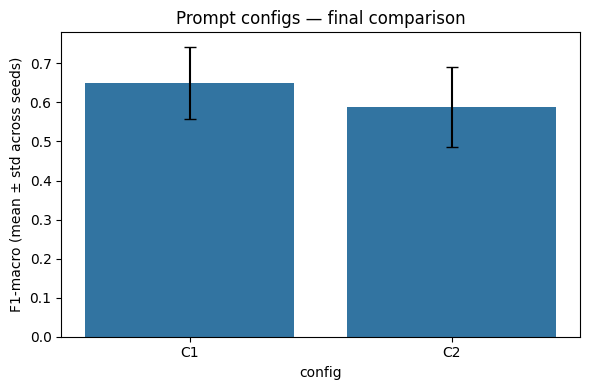

In [10]:
import matplotlib.pyplot as plt, seaborn as sns

summary = []
for name, f1s in scores.items():
    summary.append({"config": name, "f1_mean": np.mean(f1s), "f1_std": np.std(f1s)})
final_df = pd.DataFrame(summary).sort_values("f1_mean", ascending=False)
final_df.to_csv(os.path.join(OUT_DIR, "final_summary.csv"), index=False)
final_df

plt.figure(figsize=(6, 4))
sns.barplot(data=final_df, x="config", y="f1_mean", errorbar=None)
for i, r in final_df.reset_index(drop=True).iterrows():
    plt.errorbar(
        i, r["f1_mean"], yerr=r["f1_std"], fmt="none", capsize=4, color="black"
    )
plt.ylabel("F1-macro (mean ± std across seeds)")
plt.title("Prompt configs — final comparison")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "final_bar.png"), dpi=150)
plt.show()